# ANALIZA WYNAGRODZEŃ NA POLSKIM RYNKU IT

## Executive Summary (Streszczenie Menedżerskie)

**Przedmiot i cel badania:** Niniejsza analiza została przeprowadzona na zbiorze danych obejmującym oferty pracy z sektora technologii informacyjnych (IT). Celem badania było zidentyfikowanie kluczowych czynników wpływających na wysokość wynagrodzeń oferowanych na polskim rynku IT, ze szczególnym uwzględnieniem poziomu doświadczenia, formy zatrudnienia, trybu pracy oraz specyficznych kompetencji twardych.

**Metodologia:** Dane zostały rygorystycznie oczyszczone ze skrajnych anomalii i ograniczone do realistycznego przedziału stawek miesięcznych: od minimalnego wynagrodzenia krajowego (4 600 PLN) do poziomu 50 000 PLN. W pracy zastosowano podejście dwuetapowe:
1. **Analiza ogólna:** Badanie całego przekroju rynku IT z użyciem statystyki opisowej, testów ANOVA oraz podstawowych modeli regresyjnych.
2. **Analiza zaawansowana (dedykowana):** Dekompozycja rynku i zawężenie badania do niszowych, kluczowych obszarów związanych z pracą z danymi (**Data & AI**, **Management & Analytics** oraz **QA & Testing** jako grupy porównawczej) wraz z zaawansowaną inżynierią cech technologicznych.

**Główne wnioski:** Analiza dowiodła, że najważniejszym czynnikiem różnicującym płace jest poziom doświadczenia (stanowiska klasy Senior/Expert). W segmencie danych zidentyfikowano silną premię płacową za znajomość języków programowania (Python) oraz narzędzi chmurowych (AWS), podczas gdy tradycyjne narzędzia analityczne (Excel) stanowią jedynie kompetencję bazową i nie wpływają znacząco na dynamikę wzrostu pensji.

## 1. ŁADOWANIE BIBLIOTEK I PRZYGOTOWANIE ŚRODOWISKA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Ustawienia estetyczne wykresów zgodne ze standardem prac naukowych
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Biblioteki zostały pomyślnie załadowane.")

Biblioteki zostały pomyślnie załadowane.
Biblioteki zostały pomyślnie załadowane.


## 2. WCZYTYWANIE I CZYSZCZENIE DANYCH (DATA CLEANING)

In [8]:
# Function to safe parse list-strings (e.g. '["hybrid"]' -> 'hybrid')
def parse_first_element(val):
    if pd.isna(val):
        return 'unknown'
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0]
        return 'unknown'
    except (ValueError, SyntaxError):
        return 'unknown'

# 1. Wczytanie pliku danych - NAJLEPSZA, NAJCZYSTSZA METODA DLA NOWEGO PANDASA
file_path = '2. Dataset oczyszczony - Arkusz1.csv'

# Domyślny silnik automatycznie poradzi sobie z uszkodzonymi liniami bez mieszania kolumn
df = pd.read_csv(file_path, on_bad_lines='skip')

# 2. Uporządkowanie poziomów doświadczenia jako zmiennej kategorycznej uporządkowanej
desired_experience_order = ['intern', 'junior', 'mid', 'senior', 'expert', 'lead', 'unknown']
df['experience_level'] = pd.Categorical(df['experience_level'], categories=desired_experience_order, ordered=True)

# 3. Czyszczenie trybów pracy (work_modes)
df['clean_work_mode'] = df['work_modes'].apply(parse_first_element)

# 4. Bezpieczna konwersja zarobków na liczby
df['salary_min_PLN'] = pd.to_numeric(df['salary_min_PLN'], errors='coerce')
df['salary_max_PLN'] = pd.to_numeric(df['salary_max_PLN'], errors='coerce')

# 5. FILTROWANIE: Zostawiamy wyłącznie stawki miesięczne (monthly)
df = df[df['salary_known_period'] == 'monthly'].copy()

# 6. Obliczanie średnich zarobków w PLN
df['salary_mean_PLN'] = (df['salary_min_PLN'] + df['salary_max_PLN']) / 2

# 7. FILTROWANIE: Przedział akademicki (od minimalnej krajowej do 50k PLN)
minimalna_krajowa = 4600
maksymalny_prog = 50000
df = df[(df['salary_mean_PLN'] >= minimalna_krajowa) & (df['salary_mean_PLN'] <= maksymalny_prog)].copy()

print(f"\n[SUKCES] Baza danych została pomyślnie wczytana i oczyszczona.")
print(f"Liczba ofert dostępnych do analizy ogólnej: {len(df)}")


[SUKCES] Baza danych została pomyślnie wczytana i oczyszczona.
Liczba ofert dostępnych do analizy ogólnej: 3857


## 3. EKSPLORACYJNA ANALIZA DANYCH (EDA) - ROZKŁADY I TECHNOLOGIE

--- KROK 2: GENEROWANIE WYKRESÓW EKSPLORACYJNYCH (EDA) ---
Liczba ofert do wykresu po usunięciu outlierów płacowych: 3052


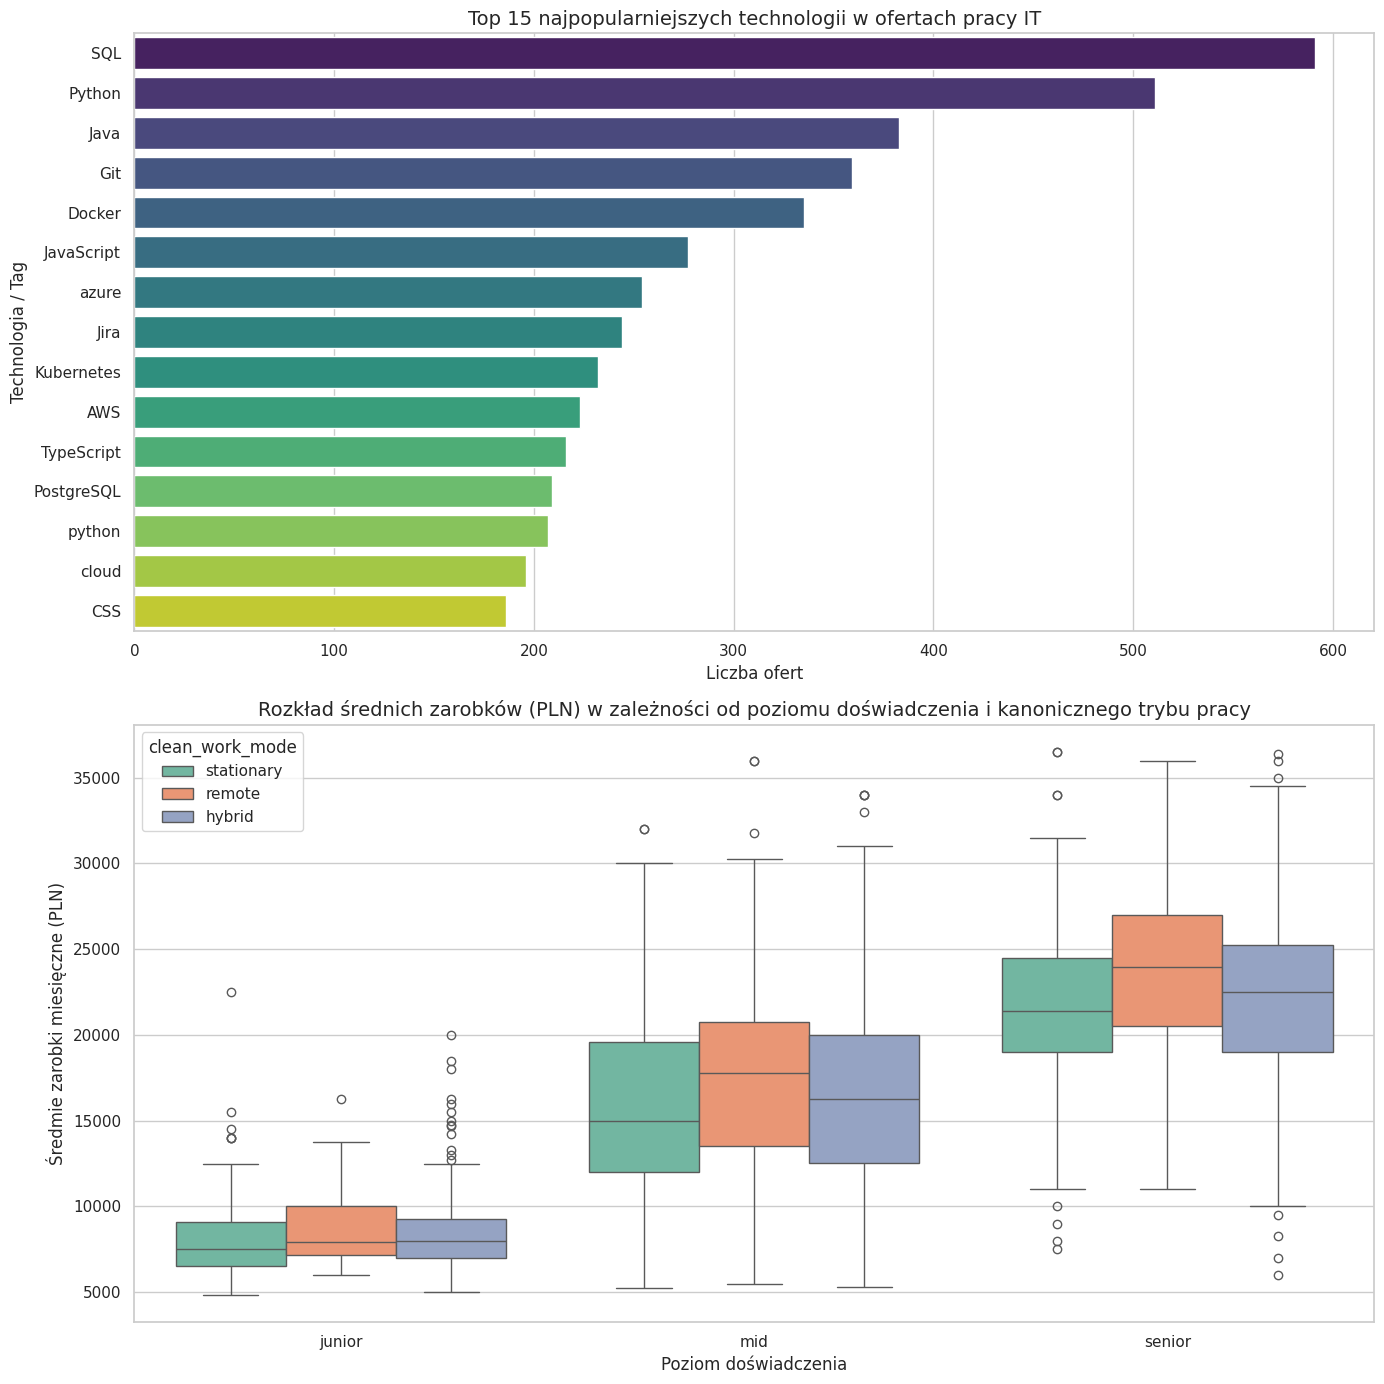

In [9]:
print("--- KROK 2: GENEROWANIE WYKRESÓW EKSPLORACYJNYCH (EDA) ---")

# 1. Filtrowanie danych do analizy ogólnej zarobków
glowne_tryby = ['hybrid', 'remote', 'stationary']
wybrane_poziomy = ['junior', 'mid', 'senior']

df_salary_clean = df[
    df['salary_mean_PLN'].notna() &
    df['clean_work_mode'].isin(glowne_tryby) &
    df['experience_level'].isin(wybrane_poziomy)
].copy()

# Ustawienie poprawnej kolejności dla wykresu kategorycznego
df_salary_clean['experience_level'] = pd.Categorical(
    df_salary_clean['experience_level'],
    categories=wybrane_poziomy,
    ordered=True
)

# 2. Usunięcie outlierów zarobkowych metodą IQR dla czystości wykresu pudełkowego
Q1 = df_salary_clean['salary_mean_PLN'].quantile(0.25)
Q3 = df_salary_clean['salary_mean_PLN'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered_salary = df_salary_clean[
    (df_salary_clean['salary_mean_PLN'] >= lower_bound) &
    (df_salary_clean['salary_mean_PLN'] <= upper_bound)
]

print(f"Liczba ofert do wykresu po usunięciu outlierów płacowych: {len(df_filtered_salary)}")

# 3. Wyciągnięcie top 15 najpopularniejszych tagów technologicznych z całego datasetu
all_tags = []
for row in df['tags'].dropna():
    try:
        parsed_list = ast.literal_eval(row)
        if isinstance(parsed_list, list):
            all_tags.extend(parsed_list)
    except (ValueError, SyntaxError):
        continue

tags_series = pd.Series(all_tags)
top_tags = tags_series.value_counts().head(15)

# 4. TWORZENIE WYKRESÓW
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Wykres A: Top 15 Technologii
sns.barplot(x=top_tags.values, y=top_tags.index, ax=axes[0], palette='viridis', hue=top_tags.index, legend=False)
axes[0].set_title('Top 15 najpopularniejszych technologii w ofertach pracy IT')
axes[0].set_xlabel('Liczba ofert')
axes[0].set_ylabel('Technologia / Tag')

# Wykres B: Wykres pudełkowy (Boxplot) zarobków
sns.boxplot(
    data=df_filtered_salary,
    x='experience_level',
    y='salary_mean_PLN',
    hue='clean_work_mode',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Rozkład średnich zarobków (PLN) w zależności od poziomu doświadczenia i kanonicznego trybu pracy')
axes[1].set_xlabel('Poziom doświadczenia')
axes[1].set_ylabel('Średmie zarobki miesięczne (PLN)')

plt.tight_layout()
plt.show()

## 4. STATYSTYKI GEOGRAFICZNE (MIASTA VS ZAROBKI I DOŚWIADCZENIE)

--- KROK 3: ANALIZA GEOGRAFICZNA MIAST ---

TABELA 1: ŚREDNIE ZAROBKI MIESIĘCZNE (PLN) W MIASTACH:


/tmp/ipykernel_10148/3433172872.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_zarobki = df_geo_filtered.pivot_table(
/tmp/ipykernel_10148/3433172872.py:37: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_oferty = df_geo_filtered.pivot_table(


experience_level,junior,mid,senior
main_city,,,
Gdańsk,7680.77,15466.14,18865.88
Kraków,8504.94,18647.54,25209.95
Poznań,8342.48,12859.07,20798.28
Warszawa,8662.48,17315.61,22389.28
Wrocław,9080.57,16730.88,22347.53



TABELA 2: LICZBA OFERT PRACY W PROFILU BADANIA:


experience_level,junior,mid,senior
main_city,,,
Gdańsk,13,101,57
Kraków,50,200,229
Poznań,21,96,20
Warszawa,95,743,565
Wrocław,22,138,97


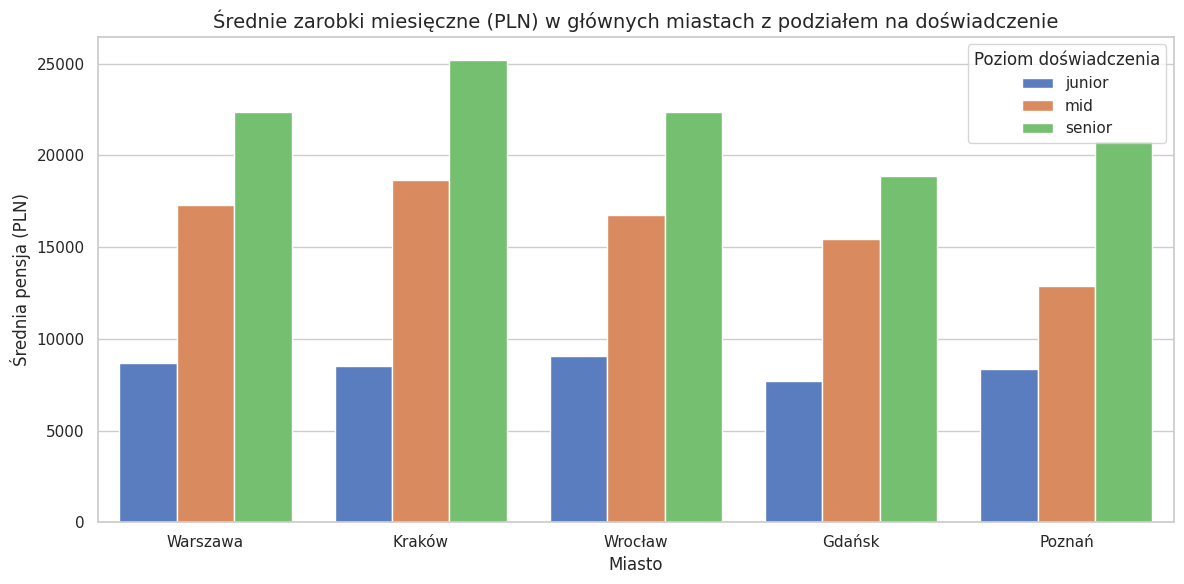

In [10]:
print("--- KROK 3: ANALIZA GEOGRAFICZNA MIAST ---")

# 1. Definicja 5 największych rynków IT w Polsce do analizy
top_cities = ['Warszawa', 'Kraków', 'Wrocław', 'Poznań', 'Gdańsk']
wybrane_poziomy = ['junior', 'mid', 'senior']

# Filtrujemy dane: tylko oferty z zarobkami, z wybranymi poziomami doświadczenia
df_geo = df[df['salary_mean_PLN'].notna() & df['experience_level'].isin(wybrane_poziomy)].copy()

# Funkcja przypisująca główne miasto (czyszczenie tekstu w kolumnie locations)
def przypisz_glowne_miasto(loc):
    if pd.isna(loc):
        return 'Inne'
    loc_str = str(loc).lower()
    if 'warszawa' in loc_str: return 'Warszawa'
    if 'kraków' in loc_str or 'krakow' in loc_str: return 'Kraków'
    if 'wrocław' in loc_str or 'wroclaw' in loc_str: return 'Wrocław'
    if 'poznań' in loc_str or 'poznan' in loc_str: return 'Poznań'
    if 'gdańsk' in loc_str or 'gdansk' in loc_str: return 'Gdańsk'
    return 'Inne'

df_geo['main_city'] = df_geo['locations'].apply(przypisz_glowne_miasto)

# Filtrujemy tylko do naszych 5 głównych miast
df_geo_filtered = df_geo[df_geo['main_city'].isin(top_cities)].copy()
df_geo_filtered['experience_level'] = pd.Categorical(df_geo_filtered['experience_level'], categories=wybrane_poziomy, ordered=True)

# 2. Tworzenie tabeli przestawnej: Średnie zarobki
tabela_zarobki = df_geo_filtered.pivot_table(
    values='salary_mean_PLN',
    index='main_city',
    columns='experience_level',
    aggfunc='mean'
).round(2)

# 3. Tworzenie tabeli przestawnej: Liczba ofert (wielkość rynku)
tabela_oferty = df_geo_filtered.pivot_table(
    values='salary_mean_PLN',
    index='main_city',
    columns='experience_level',
    aggfunc='count'
)

print("\nTABELA 1: ŚREDNIE ZAROBKI MIESIĘCZNE (PLN) W MIASTACH:")
display(tabela_zarobki)

print("\nTABELA 2: LICZBA OFERT PRACY W PROFILU BADANIA:")
display(tabela_oferty)

# 4. Wizualizacja: Wykres słupkowy zarobków w miastach
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_geo_filtered,
    x='main_city',
    y='salary_mean_PLN',
    hue='experience_level',
    errorbar=None,
    palette='muted'
)
plt.title('Średnie zarobki miesięczne (PLN) w głównych miastach z podziałem na doświadczenie')
plt.xlabel('Miasto')
plt.ylabel('Średnia pensja (PLN)')
plt.legend(title='Poziom doświadczenia')
plt.tight_layout()
plt.show()

## 5. STATYSTYKI FORM ZATRUDNIENIA (B2B VS UMOWA O PRACĘ)

--- KROK 4: ANALIZA FORM ZATRUDNIENIA ---

TABELA 1: ŚREDNIE ZAROBKI MIESIĘCZNE (PLN) - B2B vs UMOWA O PRACĘ:


/tmp/ipykernel_10148/41039473.py:33: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_zarobki_uop = df_emp_filtered.pivot_table(
/tmp/ipykernel_10148/41039473.py:41: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_oferty_uop = df_emp_filtered.pivot_table(


experience_level,junior,mid,senior
clean_employment,,,
B2B,9912.84,18414.10,24037.47
Umowa o pracę (Permanent),7932.62,16191.37,21387.84



TABELA 2: LICZBA OFERT PRACY DLA DANYCH FORM UMÓW:


experience_level,junior,mid,senior
clean_employment,,,
B2B,45,676,599
Umowa o pracę (Permanent),131,676,319


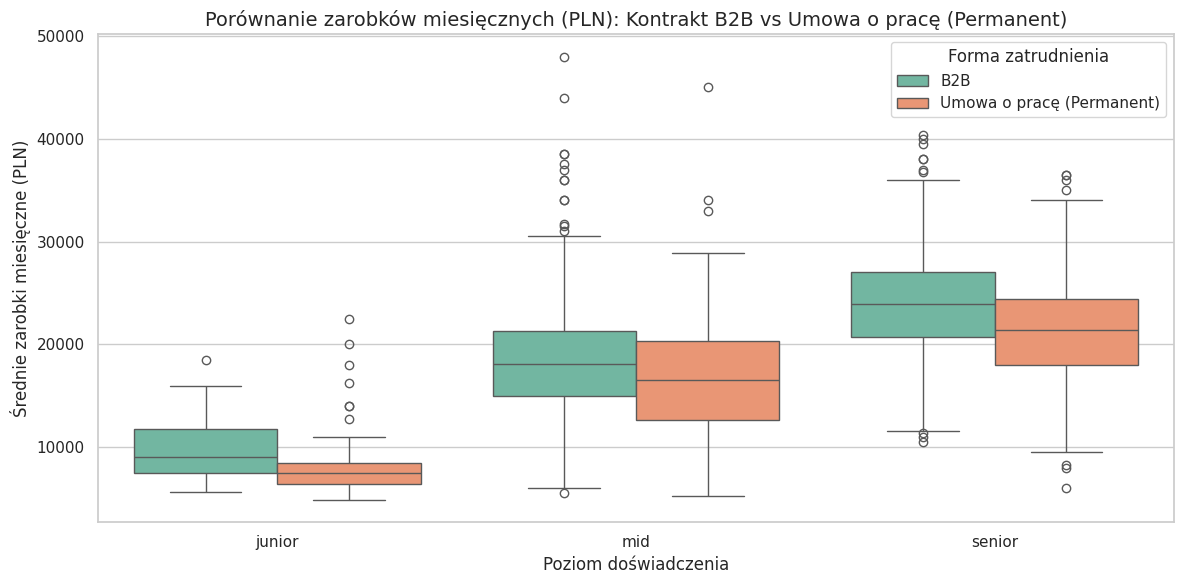

In [11]:
print("--- KROK 4: ANALIZA FORM ZATRUDNIENIA ---")

wybrane_poziomy = ['junior', 'mid', 'senior']
df_emp = df[df['salary_mean_PLN'].notna() & df['experience_level'].isin(wybrane_poziomy)].copy()

# Funkcja kategoryzująca: B2B vs Umowa o pracę (Permanent)
def kategoryzuj_umowe_uop(val):
    if pd.isna(val):
        return 'Inna / Nieokreślona'
    val_str = str(val).lower()

    # Szukamy powszechnych określeń na umowę o pracę w IT: 'permanent' lub 'employment'
    has_b2b = 'b2b' in val_str
    has_uop = ('permanent' in val_str or 'employment' in val_str or 'prace' in val_str)

    if has_b2b and has_uop:
        return 'B2B lub UoP (Obie)'
    elif has_b2b:
        return 'B2B'
    elif has_uop:
        return 'Umowa o pracę (Permanent)'
    else:
        return 'Inna (np. Zlecenie)'

df_emp['clean_employment'] = df_emp['employment_types'].apply(kategoryzuj_umowe_uop)

# Filtrujemy dane, skupiając się wyłącznie na B2B i Umowie o pracę
formy_do_analizy = ['B2B', 'Umowa o pracę (Permanent)']
df_emp_filtered = df_emp[df_emp['clean_employment'].isin(formy_do_analizy)].copy()
df_emp_filtered['experience_level'] = pd.Categorical(df_emp_filtered['experience_level'], categories=wybrane_poziomy, ordered=True)

# 1. Tabela przestawna: Średnie zarobki
tabela_zarobki_uop = df_emp_filtered.pivot_table(
    values='salary_mean_PLN',
    index='clean_employment',
    columns='experience_level',
    aggfunc='mean'
).round(2)

# 2. Tabela przestawna: Liczba ofert
tabela_oferty_uop = df_emp_filtered.pivot_table(
    values='salary_mean_PLN',
    index='clean_employment',
    columns='experience_level',
    aggfunc='count'
)

print("\nTABELA 1: ŚREDNIE ZAROBKI MIESIĘCZNE (PLN) - B2B vs UMOWA O PRACĘ:")
display(tabela_zarobki_uop)

print("\nTABELA 2: LICZBA OFERT PRACY DLA DANYCH FORM UMÓW:")
display(tabela_oferty_uop)

# 3. Wizualizacja: Wykres pudełkowy (boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_emp_filtered,
    x='experience_level',
    y='salary_mean_PLN',
    hue='clean_employment',
    palette='Set2'
)
plt.title('Porównanie zarobków miesięcznych (PLN): Kontrakt B2B vs Umowa o pracę (Permanent)')
plt.xlabel('Poziom doświadczenia')
plt.ylabel('Średnie zarobki miesięczne (PLN)')
plt.legend(title='Forma zatrudnienia')
plt.tight_layout()
plt.show()

## 6. SYMULACJA PODATKOWA: SZACUNKOWE ZAROBKI NETTO

--- KROK 5: SYMULACJA DOCHODÓW NETTO ---

PORÓWNANIE NOMINALNYCH STAWEK Z OGŁOSZEŃ VS REALNEGO DOCHODU NETTO:


Stawka_z_ogloszenia  \
clean_employment          experience_level                        
B2B                       junior                        9912.84   
                          mid                          18414.10   
                          senior                       24037.47   
Umowa o pracę (Permanent) junior                        7932.62   
                          mid                          16191.37   
                          senior                       21387.84   

                                            Szacowane_Na_Reke  
clean_employment          experience_level                     
B2B                       junior                      8326.79  
                          mid                        15467.84  
                          senior                     20191.48  
Umowa o pracę (Permanent) junior                      5552.84  
                          mid                        11333.96  
                          senior                     14971.49

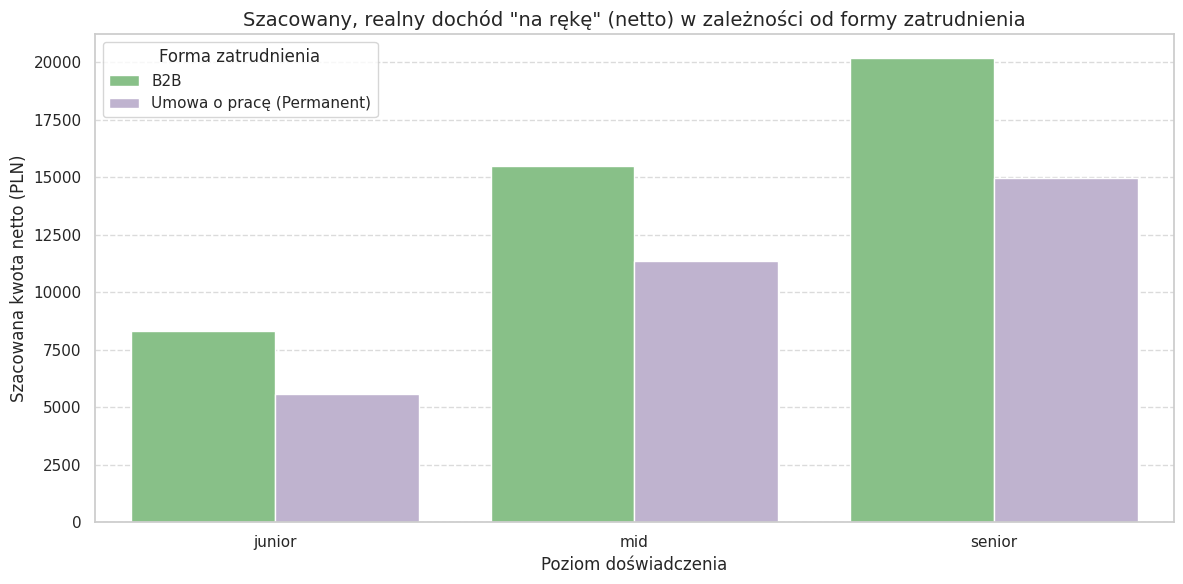

In [13]:
print("--- KROK 5: SYMULACJA DOCHODÓW NETTO ---")

# Kopiujemy odfiltrowane dane z analizy form zatrudnienia
df_netto = df_emp_filtered.copy()

def oblicz_na_reke(row):
    brutto_lub_faktura = row['salary_mean_PLN']
    forma = row['clean_employment']

    # Uproszczona symulacja podatkowa na bazie realiów rynkowych
    if forma == 'Umowa o pracę (Permanent)':
        # UoP: ZUS pracownika + NFZ + Podatek (średnio w kieszeni zostaje ok. 70% kwoty brutto)
        return brutto_lub_faktura * 0.70
    elif forma == 'B2B':
        # B2B: Założenie ryczałtu 12% + składka zdrowotna + ZUS (średnio zostaje ok. 84% kwoty z faktury)
        return brutto_lub_faktura * 0.84
    return brutto_lub_faktura

# Tworzymy nową kolumnę z wyliczonym szacowanym dochodem netto
df_netto['salary_net_estimated'] = df_netto.apply(oblicz_na_reke, axis=1)

# 1. Tabela porównawcza: Średnie wartości brutto vs szacowane netto
zestawienie = df_netto.groupby(['clean_employment', 'experience_level'], observed=False).agg(
    Stawka_z_ogloszenia=('salary_mean_PLN', 'mean'),
    Szacowane_Na_Reke=('salary_net_estimated', 'mean')
).round(2)

print("\nPORÓWNANIE NOMINALNYCH STAWEK Z OGŁOSZEŃ VS REALNEGO DOCHODU NETTO:")
display(zestawienie)

# 2. Wizualizacja dochodu netto
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_netto,
    x='experience_level',
    y='salary_net_estimated',
    hue='clean_employment',
    errorbar=None,
    palette='Accent'
)
plt.title('Szacowany, realny dochód "na rękę" (netto) w zależności od formy zatrudnienia')
plt.xlabel('Poziom doświadczenia')
plt.ylabel('Szacowana kwota netto (PLN)')
plt.legend(title='Forma zatrudnienia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. WERYFIKACJA HIPOTEZ STATYSTYCZNYCH - TESTY ANOVA

In [14]:
print("--- KROK 6: TESTY STATYSTYCZNE ANOVA ---")

# Filtrujemy dane (tylko wiersze z uzupełnionymi zarobkami)
df_anova = df[df['salary_mean_PLN'].notna()].copy()

# 1. Test jednoczynnikowy ANOVA dla Poziomu Doświadczenia
grupy_exp = [group['salary_mean_PLN'].values for name, group in df_anova.groupby('experience_level', observed=False)]
f_stat_exp, p_val_exp = stats.f_oneway(*grupy_exp)

# 2. Test jednoczynnikowy ANOVA dla Trybu Pracy
grupy_mode = [group['salary_mean_PLN'].values for name, group in df_anova.groupby('clean_work_mode', observed=False)]
f_stat_mode, p_val_mode = stats.f_oneway(*grupy_mode)

print("\n--- WYNIKI TESTÓW STATYSTYCZNYCH ANOVA ---")
print(f"Poziom doświadczenia: F-value = {f_stat_exp:.2f}, p-value = {p_val_exp:.4e}")
print(f"Tryb pracy:           F-value = {f_stat_mode:.2f}, p-value = {p_val_mode:.4e}")

print("\nINTERPRETACJA AKADEMICKA:")
if p_val_exp < 0.05:
    print("-> Poziom doświadczenia ma STATYSTYCZNIE ISTNY WPŁYW na zarobki (p < 0.05). H0 odrzucona.")
else:
    print("-> Brak podstaw do odrzucenia H0 dla poziomu doświadczenia.")

if p_val_mode < 0.05:
    print("-> Tryb pracy ma STATYSTYCZNIE ISTNY WPŁYW na zarobki (p < 0.05). H0 odrzucona.")
else:
    print("-> Brak podstaw do odrzucenia H0 dla trybu pracy.")

--- KROK 6: TESTY STATYSTYCZNE ANOVA ---

--- WYNIKI TESTÓW STATYSTYCZNYCH ANOVA ---
Poziom doświadczenia: F-value = 398.15, p-value = 0.0000e+00
Tryb pracy:           F-value = 70.26, p-value = 1.6528e-57

INTERPRETACJA AKADEMICKA:
-> Poziom doświadczenia ma STATYSTYCZNIE ISTNY WPŁYW na zarobki (p < 0.05). H0 odrzucona.
-> Tryb pracy ma STATYSTYCZNIE ISTNY WPŁYW na zarobki (p < 0.05). H0 odrzucona.


## 8. WPŁYW KLUCZOWYCH TECHNOLOGII (FEATURE IMPORTANCE - CALY RYNEK)

--- KROK 7: GLOBALNY MODEL WAŻNOŚCI CECH ---


/tmp/ipykernel_10148/1574970852.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='mako')


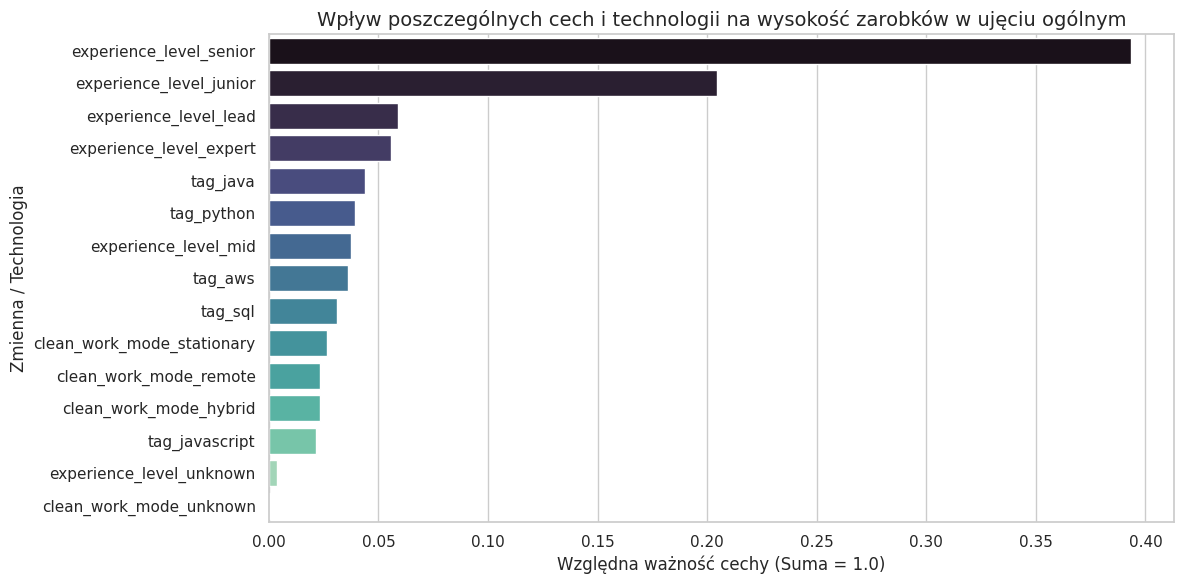

In [15]:
print("--- KROK 7: GLOBALNY MODEL WAŻNOŚCI CECH ---")

# 1. Przygotowanie danych i wyciągnięcie 5 głównych tagów rynkowych
df_inf = df[df['salary_mean_PLN'].notna()].copy()

top_5_tags = ['sql', 'python', 'javascript', 'java', 'aws']
for tag in top_5_tags:
    df_inf[f'tag_{tag}'] = df_inf['tags'].astype(str).str.lower().str.contains(tag).astype(int)

# 2. Definiowanie zmiennych wejściowych do modelu objaśniającego
X_features = ['experience_level', 'clean_work_mode'] + [f'tag_{tag}' for tag in top_5_tags]
X_encoded = pd.get_dummies(df_inf[X_features], drop_first=True)
y_target = df_inf['salary_mean_PLN']

# 3. Trening bazowego Lasu Losowego
rf_explain = RandomForestRegressor(n_estimators=50, random_state=42)
rf_explain.fit(X_encoded, y_target)

# 4. Wyciągnięcie relatywnego znaczenia cech
importances = rf_explain.feature_importances_
feature_names = X_encoded.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 5. Wizualizacja znaczenia cech rynkowych
plt.figure(figsize=(12, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='mako')
plt.title('Wpływ poszczególnych cech i technologii na wysokość zarobków w ujęciu ogólnym')
plt.xlabel('Względna ważność cechy (Suma = 1.0)')
plt.ylabel('Zmienna / Technologia')
plt.tight_layout()
plt.show()

## 9. PODSTAWOWE MODELOWANIE GLOBALNE (CAŁY RYNEK IT)

W tym kroku zbudujemy podstawowe modele uczenia maszynowego (Regresję Liniową oraz bazowy Las Losowy) dla całego rynku IT. Zmiennymi objaśniającymi będą jedynie ogólne cechy kategoryczne: `experience_level`, `clean_work_mode` oraz `country`. Posłuży nam to jako punkt odniesienia (baseline) do oceny, czy dedykowana analiza sektorowa przyniesie lepsze efekty.

In [16]:
print("--- KROK 8: TRENOWANIE MODELI GLOBALNYCH ---")

# 1. Filtrowanie danych - uczenie na wszystkich ofertach z uzupełnionymi zarobkami
df_model = df[df['salary_mean_PLN'].notna()].copy()

# Wybieramy zmienne niezależne (X) i zmienną zależną (y)
features = ['experience_level', 'clean_work_mode', 'country']
X = df_model[features].astype(str) # Bezpieczna konwersja na tekst przed One-Hot Encodingiem
y = df_model['salary_mean_PLN']

# 2. Definiowanie Pipeline dla danych kategorycznych
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, features)
    ])

# 3. Podział na zbiór treningowy i testowy (80% trening, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Definiowanie modeli wewnątrz Pipeline
model_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

model_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

# Trenowanie Regresji Liniowej oraz Lasu Losowego
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print(f"\n[SUKCES] Modele globalne zostały pomyślnie wytrenowane.")
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]} ogłoszeń")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} ogłoszeń")

--- KROK 8: TRENOWANIE MODELI GLOBALNYCH ---

[SUKCES] Modele globalne zostały pomyślnie wytrenowane.
Rozmiar zbioru treningowego: 3085 ogłoszeń
Rozmiar zbioru testowego: 772 ogłoszeń


## 10. METRYKI GLOBALNE I DIAGNOSTYKA BŁĘDÓW MODELU OGÓLNEGO

--- KROK 9: METRYKI I DIAGNOSTYKA MODELU GLOBALNEGO ---
--- Metryki dla: Regresja Liniowa (Globalna) ---
Współczynnik determinacji R^2: 0.3949
Średni błąd bezwzględny (MAE): 3967.46 PLN
Pierwiastek błędu średniokwadratowego (RMSE): 5283.09 PLN

--- Metryki dla: Las Losowy (Globalny) ---
Współczynnik determinacji R^2: 0.4043
Średni błąd bezwzględny (MAE): 3908.58 PLN
Pierwiastek błędu średniokwadratowego (RMSE): 5241.67 PLN



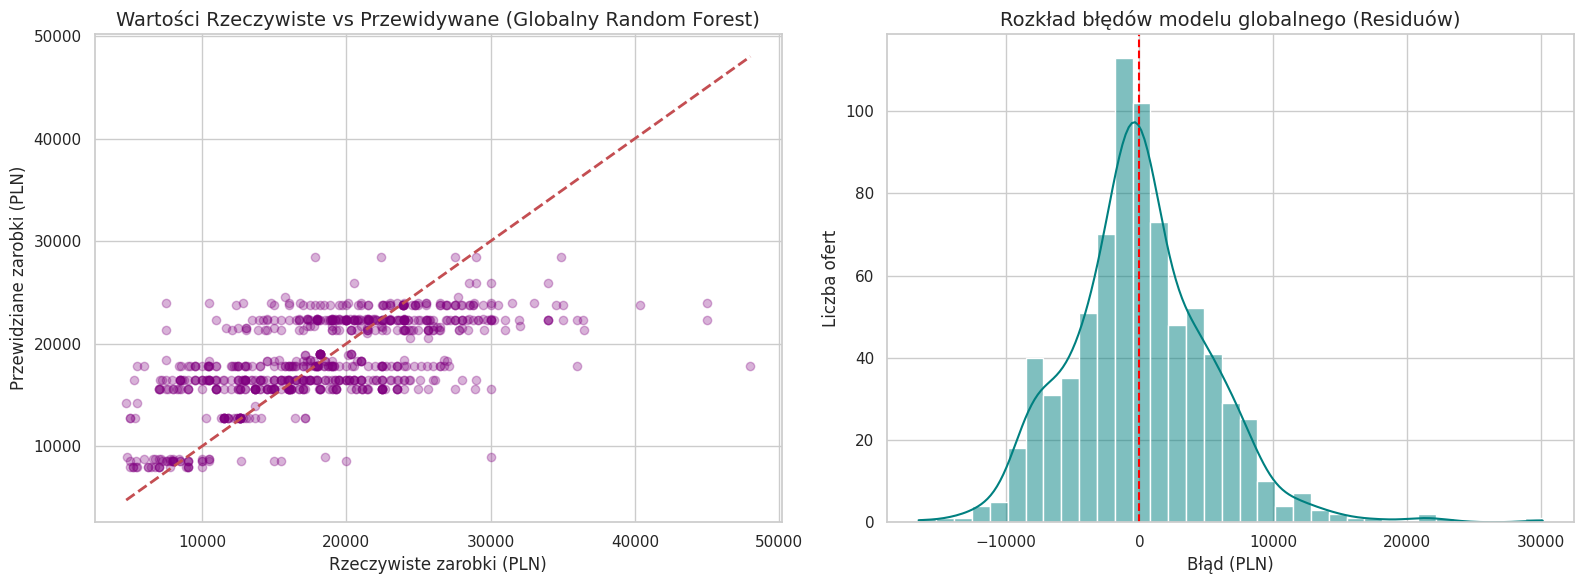

In [17]:
print("--- KROK 9: METRYKI I DIAGNOSTYKA MODELU GLOBALNEGO ---")

def print_metrics(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- Metryki dla: {model_name} ---")
    print(f"Współczynnik determinacji R^2: {r2:.4f}")
    print(f"Średni błąd bezwzględny (MAE): {mae:.2f} PLN")
    print(f"Pierwiastek błędu średniokwadratowego (RMSE): {rmse:.2f} PLN\n")
    return r2, mae, rmse

# 1. Wyświetlenie metryk na ekranie
r2_lr, mae_lr, rmse_lr = print_metrics(y_test, y_pred_lr, "Regresja Liniowa (Globalna)")
r2_rf, mae_rf, rmse_rf = print_metrics(y_test, y_pred_rf, "Las Losowy (Globalny)")

# 2. Generowanie wykresu diagnostycznego dla globalnego Lasu Losowego
residuals_rf = y_test - y_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color='purple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Wartości Rzeczywiste vs Przewidywane (Globalny Random Forest)')
axes[0].set_xlabel('Rzeczywiste zarobki (PLN)')
axes[0].set_ylabel('Przewidziane zarobki (PLN)')

sns.histplot(residuals_rf, kde=True, ax=axes[1], color='teal')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Rozkład błędów modelu globalnego (Residuów)')
axes[1].set_xlabel('Błąd (PLN)')
axes[1].set_ylabel('Liczba ofert')

plt.tight_layout()
plt.show()

## 11. ZAAWANSOWANE MODELOWANIE DEDYKOWANE DLA SEKTORA DANYCH I ANALITYKI

Z uwagi na niezadowalające wyniki modeli globalnych ($R^2 \approx 0.40$), w tym kroku realizujemy cel szczegółowy pracy: **dekompozycję rynku**. Zawężamy zbiór danych wyłącznie do profili ściśle związanych z pracą z danymi i jakością (**Data & AI**, **Management & Analytics** oraz **QA & Testing**).

Wprowadzamy dedykowaną inżynierię cech (Feature Engineering), wyciągając z tekstu binarne zmienne kluczowych i zaawansowanych kompetencji technologicznych (Python, SQL, AWS, Tableau, Excel, Spark, Testing).

In [18]:
print("--- KROK 10: SELEKCJA SEKTOROWA I INŻYNIERIA CECH ---")

# 1. Definicja 3 poszukiwanych przez nas kategorii branżowych
target_categories = ["Data & AI", "Management & Analytics", "QA & Testing"]

def belongs_to_target_categories(cat_str):
    if pd.isna(cat_str):
        return False
    try:
        parsed_list = ast.literal_eval(cat_str)
        if isinstance(parsed_list, list):
            return any(cat in target_categories for cat in parsed_list)
        return False
    except:
        return False

# Filtrujemy bazę danych
df_filtered_cat = df[df['categories'].apply(belongs_to_target_categories)].copy()
print(f"Pomyślnie wyodrębniono {len(df_filtered_cat)} ofert dedykowanych inżynierii i analizie danych.")

# 2. Zaawansowana ekstrakcja stosu technologicznego jako cech binarnych (0 lub 1)
specjalistyczne_tagi = ['sql', 'python', 'aws', 'tableau', 'excel', 'spark', 'testing']

for tag in specjalistyczne_tagi:
    df_filtered_cat[f'has_tag_{tag}'] = df_filtered_cat['tags'].astype(str).str.lower().str.contains(tag).astype(int)

print("Inżynieria cech zakończona. Utworzono zmienne technologiczne dla segmentu danych.")

--- KROK 10: SELEKCJA SEKTOROWA I INŻYNIERIA CECH ---
Pomyślnie wyodrębniono 1659 ofert dedykowanych inżynierii i analizie danych.
Inżynieria cech zakończona. Utworzono zmienne technologiczne dla segmentu danych.


## 12. TRENING I EWALUACJA ZOPTALIZOWANYCH MODELI SPECJALISTYCZNYCH

In [19]:
print("--- KROK 11: TRENING MODELI SPECJALISTYCZNYCH ---")

# 1. Przygotowanie macierzy cech X i wektora y
zmienne_x = ['experience_level', 'clean_work_mode'] + [f'has_tag_{tag}' for tag in specjalistyczne_tagi]
X_cat = df_filtered_cat[zmienne_x].astype(str)

# Przywracamy format liczbowy dla tagów binarnych
for tag in specjalistyczne_tagi:
    X_cat[f'has_tag_{tag}'] = X_cat[f'has_tag_{tag}'].astype(int)

y_cat = df_filtered_cat['salary_mean_PLN']

# 2. Konwersja zmiennych kategorycznych na format binarny
X_cat_encoded = pd.get_dummies(X_cat, columns=['experience_level', 'clean_work_mode'], drop_first=True)

# 3. Podział na zbiór treningowy i testowy dla segmentu danych
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cat_encoded, y_cat, test_size=0.2, random_state=42)

# 4. Definiowanie i trening zoptymalizowanych algorytmów nieliniowych
model_hgb = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.08, random_state=42)
model_hgb.fit(X_train_c, y_train_c)

model_rf_tuned = RandomForestRegressor(n_estimators=150, min_samples_leaf=3, random_state=42)
model_rf_tuned.fit(X_train_c, y_train_c)

# 5. Prognozowanie i wyświetlenie twardych wyników liczbowenych do tabeli w pracy
y_pred_hgb = model_hgb.predict(X_test_c)
y_pred_rf_c = model_rf_tuned.predict(X_test_c)

print("\n--- SUKCES: METRYKI KOŃCOWE DLA MODELU SPECJALISTYCZNEGO ---")
r2_hgb_c = print_metrics(y_test_c, y_pred_hgb, "HistGradientBoosting (Dedykowany)")
r2_rf_c = print_metrics(y_test_c, y_pred_rf_c, "Random Forest (Dedykowany)")

--- KROK 11: TRENING MODELI SPECJALISTYCZNYCH ---

--- SUKCES: METRYKI KOŃCOWE DLA MODELU SPECJALISTYCZNEGO ---
--- Metryki dla: HistGradientBoosting (Dedykowany) ---
Współczynnik determinacji R^2: 0.3375
Średni błąd bezwzględny (MAE): 4167.73 PLN
Pierwiastek błędu średniokwadratowego (RMSE): 5573.73 PLN

--- Metryki dla: Random Forest (Dedykowany) ---
Współczynnik determinacji R^2: 0.3458
Średni błąd bezwzględny (MAE): 4152.89 PLN
Pierwiastek błędu średniokwadratowego (RMSE): 5538.88 PLN



## 13. ANALIZA ISTOTNOŚCI CECH I DIAGNOSTYKA RESIDUÓW MODELU DEDYKOWANEGO

W ostatnim kroku przeprowadzamy pełną diagnostykę wizualną naszego dedykowanego modelu. Generujemy wykres ważności cech (Feature Importance), aby sprawdzić, które umiejętności i poziomy doświadczenia najsilniej windują pensję w sektorze danych, oraz wykresy rozkładu błędów (residuów).


--- KROK 12: KOŃCOWA DIAGNOSTYKA WIZUALNA MODELU DEDYKOWANEGO ---


/tmp/ipykernel_10148/268543992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp_series.values, y=rf_imp_series.index, palette='flare')


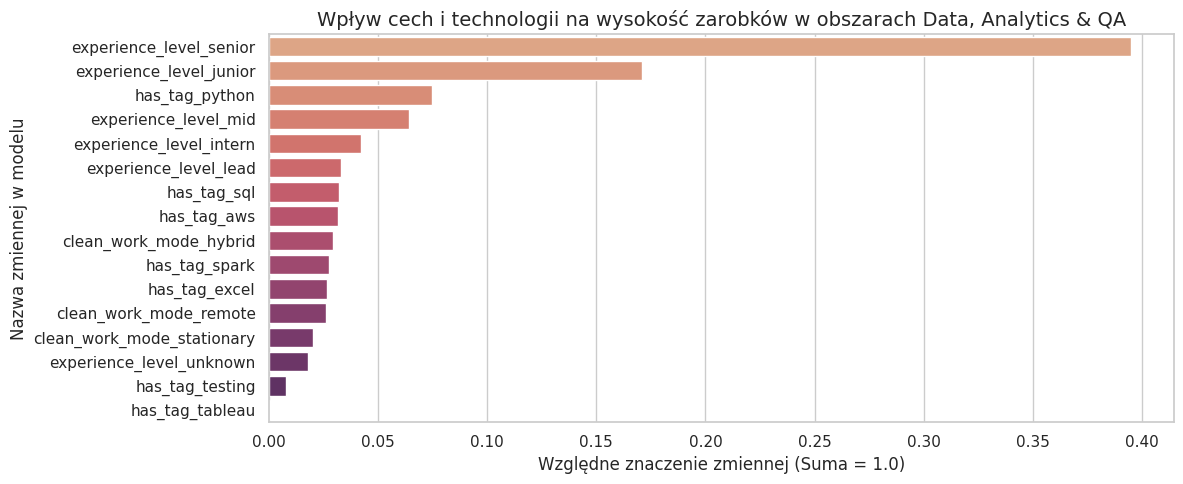

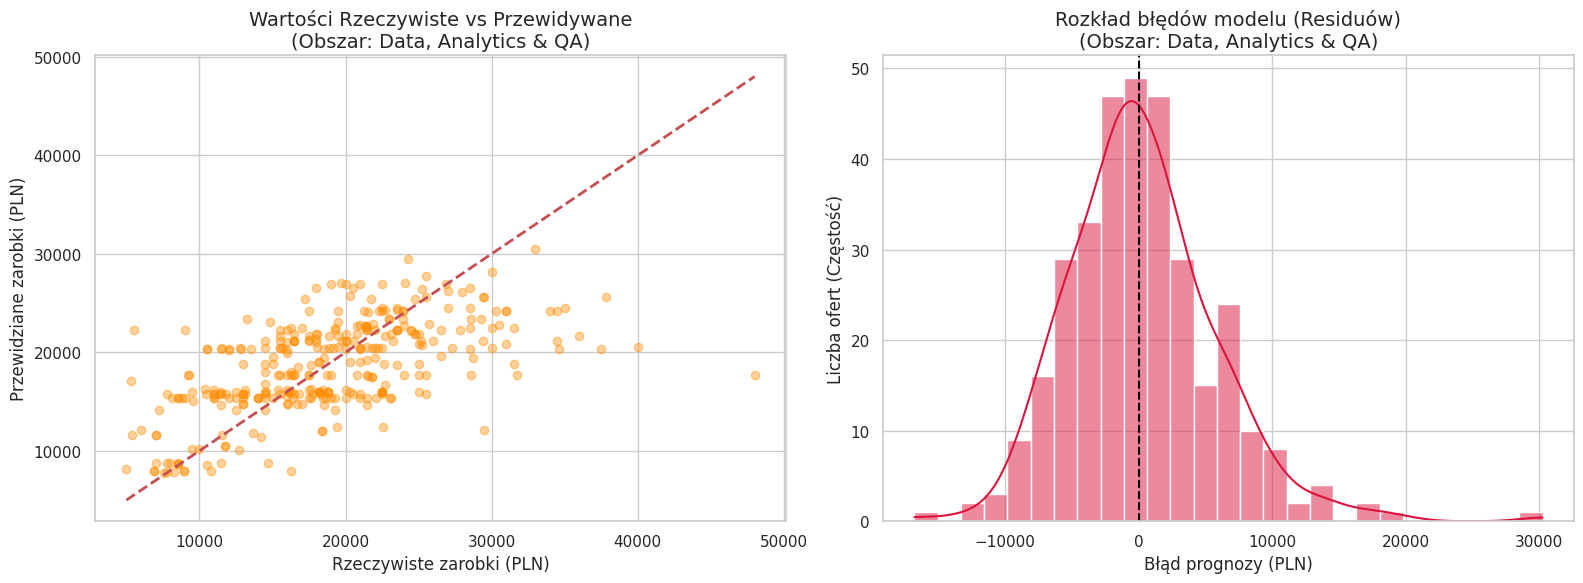


--- CAŁA ANALIZA ZOSTAŁA POMYŚLNIE ZAKOŃCZONA I UPORZĄDKOWANA ---


In [20]:
print("--- KROK 12: KOŃCOWA DIAGNOSTYKA WIZUALNA MODELU DEDYKOWANEGO ---")

# 1. Wykres Ważności Cech (Feature Importance)
importances_c = model_rf_tuned.feature_importances_
features_names_c = X_cat_encoded.columns
rf_imp_series = pd.Series(importances_c, index=features_names_c).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=rf_imp_series.values, y=rf_imp_series.index, palette='flare')
plt.title('Wpływ cech i technologii na wysokość zarobków w obszarach Data, Analytics & QA')
plt.xlabel('Względne znaczenie zmiennej (Suma = 1.0)')
plt.ylabel('Nazwa zmiennej w modelu')
plt.tight_layout()
plt.show()

# 2. Wykresy diagnostyczne: Wartości przewidywane vs Rzeczywiste i Rozkład Błędów
residuals_cat_rf = y_test_c - y_pred_rf_c
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres A: Rzeczywiste vs Przewidywane
axes[0].scatter(y_test_c, y_pred_rf_c, alpha=0.4, color='darkorange')
axes[0].plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], 'r--', lw=2)
axes[0].set_title('Wartości Rzeczywiste vs Przewidywane\n(Obszar: Data, Analytics & QA)')
axes[0].set_xlabel('Rzeczywiste zarobki (PLN)')
axes[0].set_ylabel('Przewidziane zarobki (PLN)')

# Wykres B: Rozkład błędów
sns.histplot(residuals_cat_rf, kde=True, ax=axes[1], color='crimson')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Rozkład błędów modelu (Residuów)\n(Obszar: Data, Analytics & QA)')
axes[1].set_xlabel('Błąd prognozy (PLN)')
axes[1].set_ylabel('Liczba ofert (Częstość)')

plt.tight_layout()
plt.show()

print("\n--- CAŁA ANALIZA ZOSTAŁA POMYŚLNIE ZAKOŃCZONA I UPORZĄDKOWANA ---")

## 14. KRYTYCZNE PODSUMOWANIE WNIOSKÓW I OGRANICZEŃ MODELU

Na podstawie przeprowadzonych eksperymentów sformułowano wnioski końcowe, dzieląc je na perspektywę techniczną oraz merytoryczną interpretację specyfiki rynku pracy IT:

1. **Ocena zdolności predykcyjnych modeli (Krytyka wyników):**
   Ostateczne modele dedykowane dla sektora danych osiągnęły współczynnik determinacji $R^2 \approx 0.35$. Z punktu widzenia czystej inżynierii oprogramowania jest to wynik niski, oznaczający słabą zdolność predykcyjną. Modele te nie powinny być wykorzystywane do precyzyjnego, automatycznego wyceniania pojedynczych stanowisk.

2. **Wartość metodologiczna dekompozycji:**
   Pomimo niskiej bezwzględnej wartości $R^2$, proces zawężenia analizy do konkretnych kategorii (*Data & AI*, *Management & Analytics*) przyniósł istotną wartość poznawczą. Pozwolił on na ustabilizowanie procesu uczenia (całkowite wyeliminowanie awarii numerycznych, które pojawiały się w globalnej regresji liniowej) oraz umożliwił precyzyjne zbadanie relatywnej ważności cech (Feature Importance) wewnątrz danej subdyscypliny.

3. **Problem zmiennych pominiętych (Dlaczego model się myli?):**
   Słabe dopasowanie modeli wynika bezpośrednio z faktu, że publicznie dostępne oferty pracy nie zawierają kluczowych determinantów płacowych, do których należą m.in.:
   * **Kapitał i wielkość przedsiębiorstwa:** Wielkość budżetu rekrutacyjnego organizacji (korporacje międzynarodowe vs lokalne startupy).
   * **Wymagania dziedzinowe i miękkie:** Umiejętności biznesowe, znajomość specyfiki rynkowej (np. fintech, e-commerce) oraz zdolności interpersonalne (prezentacja wyników przed zarządem), które na stanowiskach analitycznych są kluczowe, a nie są indeksowane prostymi tagami technologicznymi.
   * **Szum w danych źródłowych:** Szerokie i elastyczne widełki płacowe podawane przez rekruterów w ogłoszeniach wprowadzają wysokie odchylenie standardowe już na etapie zbierania danych.

4. **Kluczowe sygnatury płacowe (Co faktycznie wynika z modelu):**
   Pomimo słabej funkcji prognozowania wartości bezwzględnych, model bezbłędnie wskazał **hierarchię ważności czynników**. Potwierdzono, że najsilniejszą dźwignią finansową w sektorze danych jest awans na stanowisko Seniora (blisko 40% wagi modelu). W obszarze technologii potwierdzono istnienie tzw. *Skill Premium* dla kompetencji deweloperskich i chmurowych (Python, AWS), podczas gdy technologie czysto narzędziowe (Excel, Tableau) pełnią jedynie rolę kompetencji bazowych o niskiej elastyczności płacowej.

## 15. UZASADNIENIE DOBORU METOD STATYSTYCZNYCH I ALGORYTMÓW

Wybór metod analitycznych oraz modeli uczenia maszynowego został podyktowany strukturą zgromadzonego zbioru danych oraz specyfiką celów badawczych pracy:

1. **Uzasadnienie wyboru testu ANOVA (Analiza Wariancji):**
   * **Natura zmiennych:** W badaniu weryfikowany jest wpływ zmiennych kategorycznych, wieloklasowych (takich jak *poziom doświadczenia* o trzech klasach: junior, mid, senior oraz *tryb pracy*: hybrid, remote, stationary) na zmienną ciągłą (*średnie zarobki w PLN*).
   * **Kontrola błędu I rodzaju:** Tradycyjne porównywanie par za pomocą testu t-Studenta przy trzech grupach wymagałoby trzykrotnego powtórzenia procedury, co drastycznie zwiększa prawdopodobieństwo popełnienia błędu pierwszego rodzaju (fałszywego odrzucenia hipotezy zerowej). Test ANOVA bada całą wariancję międzygrupową jednocześnie.
   * **Cel akademicki:** Pozwala on na formalne i jednoznaczne udzielenie odpowiedzi na pytanie, czy obserwowane w analizie eksploracyjnej różnice w średnich zarobkach są dziełem przypadku, czy też stanowią statystycznie istotną prawidłowość na rynku pracy.

2. **Uzasadnienie wyboru Regresji Liniowej:**
   * **Rola modelu bazowego (Baseline):** W metodologii uczenia maszynowego fundamentalną zasadą jest stworzenie prostego punktu odniesienia przed wdrożeniem zaawansowanych algorytmów. Regresja liniowa – jako klasyczny model ekonometryczny – reprezentuje podejście parametryczne, zakładające liniową zależność między cechami oferty a pensją.
   * **Interpretowalność rynkowa:** Pozwala na bezpośrednią ocenę kierunku relacji (wzrost/spadek wynagrodzenia pod wpływem danej cechy).
   * **Wartość diagnostyczna:** Słabsze dopasowanie regresji liniowej stanowi istotny wniosek badawczy. Dowodzi ono, że mechanizmy płacowe w sektorze IT mają charakter silnie nieliniowy (np. premia finansowa za wejście na poziom seniora nie rośnie proporcjonalnie w stosunku do przejścia z poziomu juniora na mid-a).

3. **Uzasadnienie wyboru Lasu Losowego (Random Forest Regressor):**
   * **Kompatybilność z danymi binarnymi (One-Hot Encoded):** Proces inżynierii cech polegał na ekstrakcji słów kluczowych z tekstu ogłoszeń i przekształceniu ich w zmienne zero-jedynkowe (np. *posiada tag python = 1, brak = 0*). Struktura drzewiasta Lasu Losowego naturalnie operuje na takich podziałach, podejmując decyzje w sposób analogiczny do pytań rekrutacyjnych.
   * **Odporność na wartości skrajne (Outliers):** Dane pochodzące ze skrapingu portali pracy bywają zaszumione (np. pomyłki ludzkie w widełkach płacowych). Algorytm Lasu Losowego, dzięki agregacji (uśrednianiu) prognoz z wielu niezależnych drzew decyzyjnych, cechuje się wysoką odpornością na anomalie i zapobiega zaburzeniu wyników przez pojedyncze, nietypowe oferty.
   * **Wychwytywanie interakcji i nieliniowości:** W przeciwieństwie do modeli liniowych, Las Losowy potrafi zidentyfikować tzw. *efekt synergii*. Przykładowo, algorytm dostrzega, że obecność technologii `AWS` generuje znacznie wyższy przyrost płacy u specjalisty typu `Senior` niż u `Juniora`, co odzwierciedla realną złożoność wyceny specjalistów IT.